# (11) Retina+V1: hack

host: ```yoru```, device: ```cuda:0```

**motivation:** <br>

Kyoto16-bw

two layers:
- Retina (Gaussian + Logistic)
- V1 (Poisson)

Lower beta

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-25/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-25/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-25/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_RetinaV1'))
from figures.convergence import  plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from main.config import Config


device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

## Fit

In [3]:
cfg_layers = [
    CFG_CLASSES['gaus'](n_latents=128, beta_outer=8.0, latent_act='gompertz'),
    CFG_CLASSES['pois'](n_latents=512, beta_outer=4.0),
]
cfg = Config(
    dataset='Kyoto16-bw',
    cfg_layers=cfg_layers,
    t_train=16,
    n_iters_warmup=20,
)

In [4]:
tr = Trainer(
    model=RetinaV1(cfg),
    cfg=ConfigTrain(epochs=800),
    device=device,
)
tr.n_iters

156800

In [5]:
print(tr.model)

RetinaV1(
  (layers): ModuleDict(
    (g0): GaussianGompertzLayer(input_dim=256, latent_dim=128, temperature=1, beta_inner=1, eps=1)
    (p1): PoissonLayer(input_dim=256, latent_dim=512, temperature=1, beta_inner=1, eps=1)
  )
)

In [6]:
tr.print()

Kyoto16-bw_m(g0+gomp,p1)_t(20+16)_b(8,4)_k(128,512)
b200-ep800-lr(0.002)_temp(0.01:0.5)_gr(1000)_(2025_04_15,21:17)

In [7]:
tr.train()

epoch # 800, avg loss: 7.652: 100%|████████| 800/800 [17:40:58<00:00, 79.57s/it]


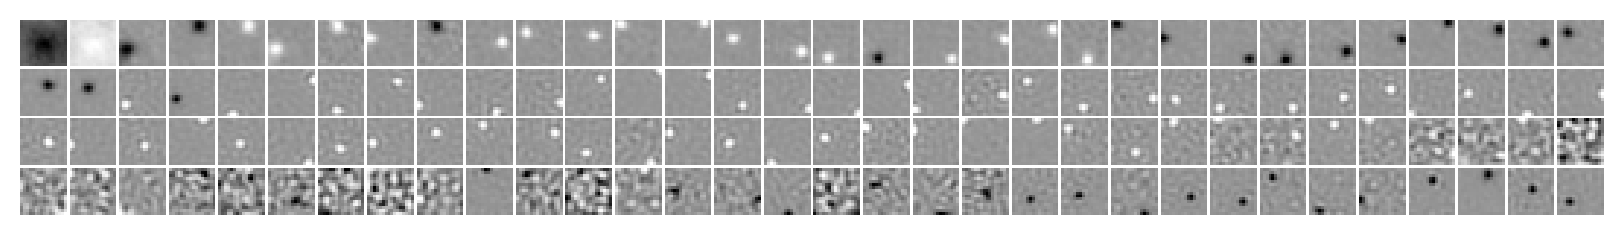

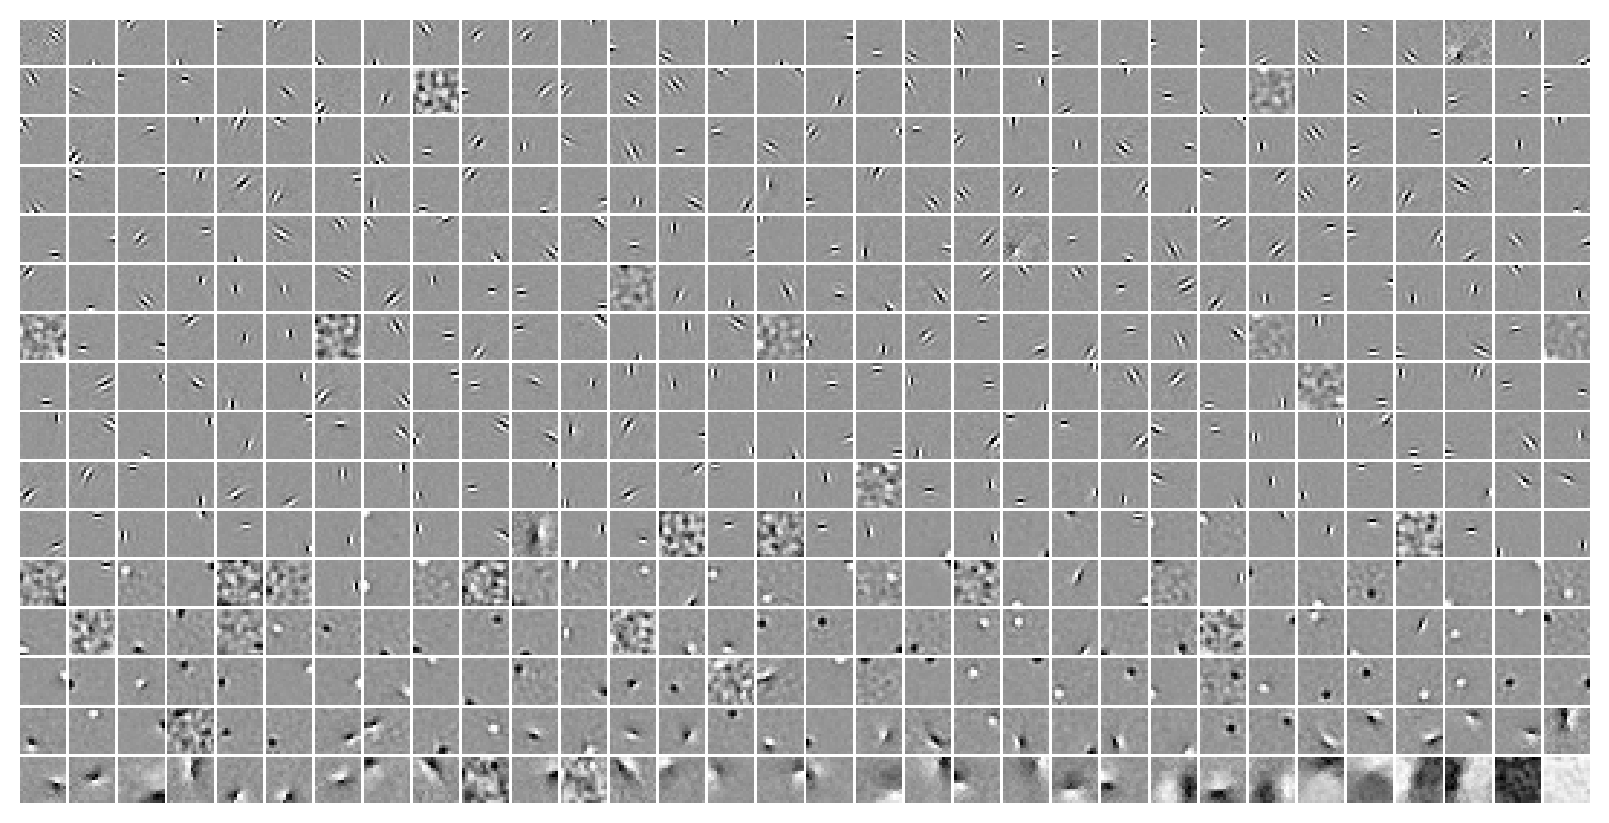

In [8]:
u0 = {
    k: tonp(layer.u_init[0].squeeze()) for
    k, layer in tr.model.layers.items()
}
for k, v in u0.items():
    kws = dict(
        order=np.argsort(v),
        nrows=16 if k == 'p1' else 4,
        method='abs-max',
    )
    tr.model.show(k, **kws);

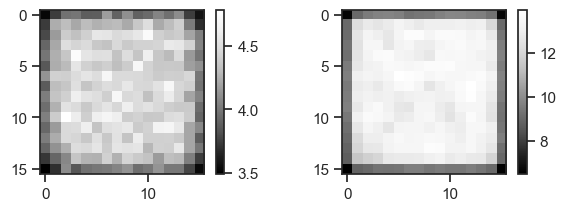

In [10]:
var = {}
for name, layer in tr.model.layers.items():
    log_sigma = layer.get_dec_log_sigma()
    var[name] = tonp(torch.exp(log_sigma ** 2).squeeze()).reshape(16, 16)

fig, axes = create_figure(1, 2)
im = axes[0].imshow(var['g0'], cmap='Greys_r')
plt.colorbar(im, ax=axes[0])

im = axes[1].imshow(var['p1'], cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

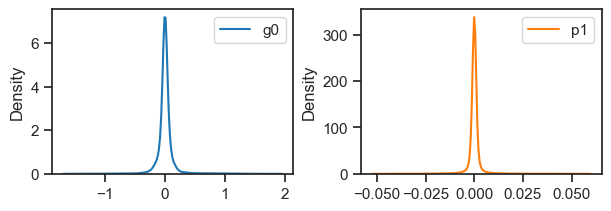

In [11]:
fig, axes = create_figure(1, len(tr.model.layers))

for i, (name, layer) in enumerate(tr.model.layers.items()):
    sns.kdeplot(tonp(layer.get_weight().ravel()), color=f'C{i}', label=name, ax=axes[i])

add_legend(axes)
plt.show()

In [12]:
tr.cfg.batch_size = 3000
tr.setup_data()

In [13]:
%%time


items = ['mse', 'r2', 'u', 'samples']

t_total = 1000

r2 = {k: np_nans(t_total) for k in tr.model.layers}
mse = {k: np_nans(t_total) for k in tr.model.layers}

true = []
pred = collections.defaultdict(list)
error = collections.defaultdict(list)

state = collections.defaultdict(list)
samples = collections.defaultdict(list)

for x, *_ in tqdm(iter(tr.dl_vld)):
    feeder = tr.get_feeder(x)
    for t in range(t_total):
        tr.model.update_time(t)
        inpt = feeder[t]
        output = tr.model.xtract_ftr(inpt, return_extras=items)
        for k, d in output.items():
            r2[k][t] = d['r2'].mean(0).item()
            mse[k][t] = d['mse'].mean(0).item()

        if (t + 1) == t_total:
            true.append(inpt.flatten(start_dim=1))
            for k, layer in tr.model.layers.items():
                pred[k].append(layer.conditional.loc)
                state[k].append(output[k]['u'])
                samples[k].append(output[k]['samples'])
                error[k].append(output[k]['error'])

del output
torch.cuda.empty_cache()
import gc
gc.collect()

true = torch.cat(true)
pred = {k: torch.cat(v) for k, v in pred.items()}
error = {k: torch.cat(v) for k, v in error.items()}
state = {k: torch.cat(v) for k, v in state.items()}
samples = {k: torch.cat(v) for k, v in samples.items()}

100%|█████████████████████████████████████████████| 4/4 [01:59<00:00, 29.83s/it]


CPU times: user 1min 59s, sys: 578 ms, total: 2min
Wall time: 2min


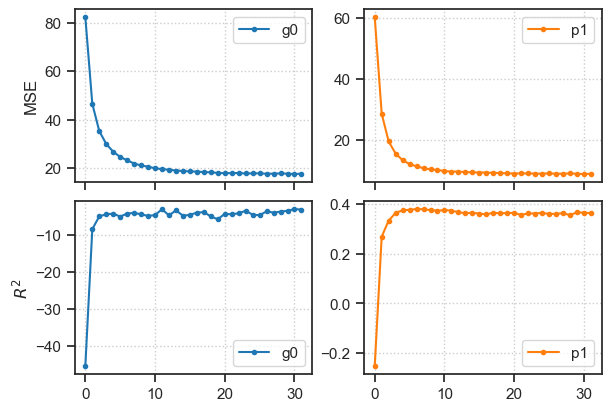

In [14]:
fig, axes = create_figure(2, len(tr.model.layers), sharex='all')

intvl = range(32)

for i, name in enumerate(tr.model.layers):
    axes[0, i].plot(mse[name][intvl], marker='.', color=f'C{i}', label=name)
    axes[1, i].plot(r2[name][intvl], marker='.', color=f'C{i}', label=name)
axes[0, 0].set(ylabel='MSE')
axes[1, 0].set(ylabel=r'$R^2$')
add_legend(axes)
add_grid(axes)
plt.show()

In [15]:
r2['p1'][-10:]

array([0.35637575, 0.36181706, 0.35880211, 0.35596925, 0.35554984,
       0.35359973, 0.36014032, 0.36031196, 0.36224642, 0.3571347 ])

In [16]:
# order: high contrast
var = tonp(torch.var(true, dim=1))
order = np.argsort(var)[::-1]

# get whitened data
_, whitened, _ = make_dataset('Kyoto16-wht', device)
whitened = whitened.tensors[0].flatten(start_dim=1)
whitened.shape

torch.Size([9821, 256])

In [17]:
def _plot_selected_samples(select_from=None, ncols=20, seed=0):
    rng = get_rng(seed)

    nrows = 6
    fig, axes = create_figure(nrows, ncols, (1 * ncols + 0.1, 1 * nrows), 'all', 'all')

    select_from = order[:200] if select_from is None else select_from
    selected_ids = rng.choice(select_from, size=ncols, replace=False)

    for i in range(ncols):
        idx = selected_ids[i]
        axes[0, i].imshow(tonp(true[idx]).reshape(16, 16), cmap='Greys_r')
        axes[1, i].imshow(tonp(pred['g0'][idx]).reshape(16, 16), cmap='Greys_r')
        axes[2, i].imshow(tonp(error['g0'][idx]).reshape(16, 16), cmap='Greys_r')
        axes[3, i].imshow(tonp(whitened[idx]).reshape(16, 16), cmap='Greys_r')
        axes[4, i].imshow(tonp(pred['p1'][idx]).reshape(16, 16), cmap='Greys_r')
        axes[5, i].imshow(tonp(error['p1'][idx]).reshape(16, 16), cmap='Greys_r')
    
    axes[0, 0].set_ylabel('img', fontsize=15)
    axes[1, 0].set_ylabel('pred\n(retina)', fontsize=15)
    axes[2, 0].set_ylabel('error\n(retina)', fontsize=15)
    axes[3, 0].set_ylabel('whitened', fontsize=15)
    axes[4, 0].set_ylabel('pred\n(v1)', fontsize=15)
    axes[5, 0].set_ylabel('error\n(v1)', fontsize=15)

    remove_ticks(axes, False)
    plt.show()

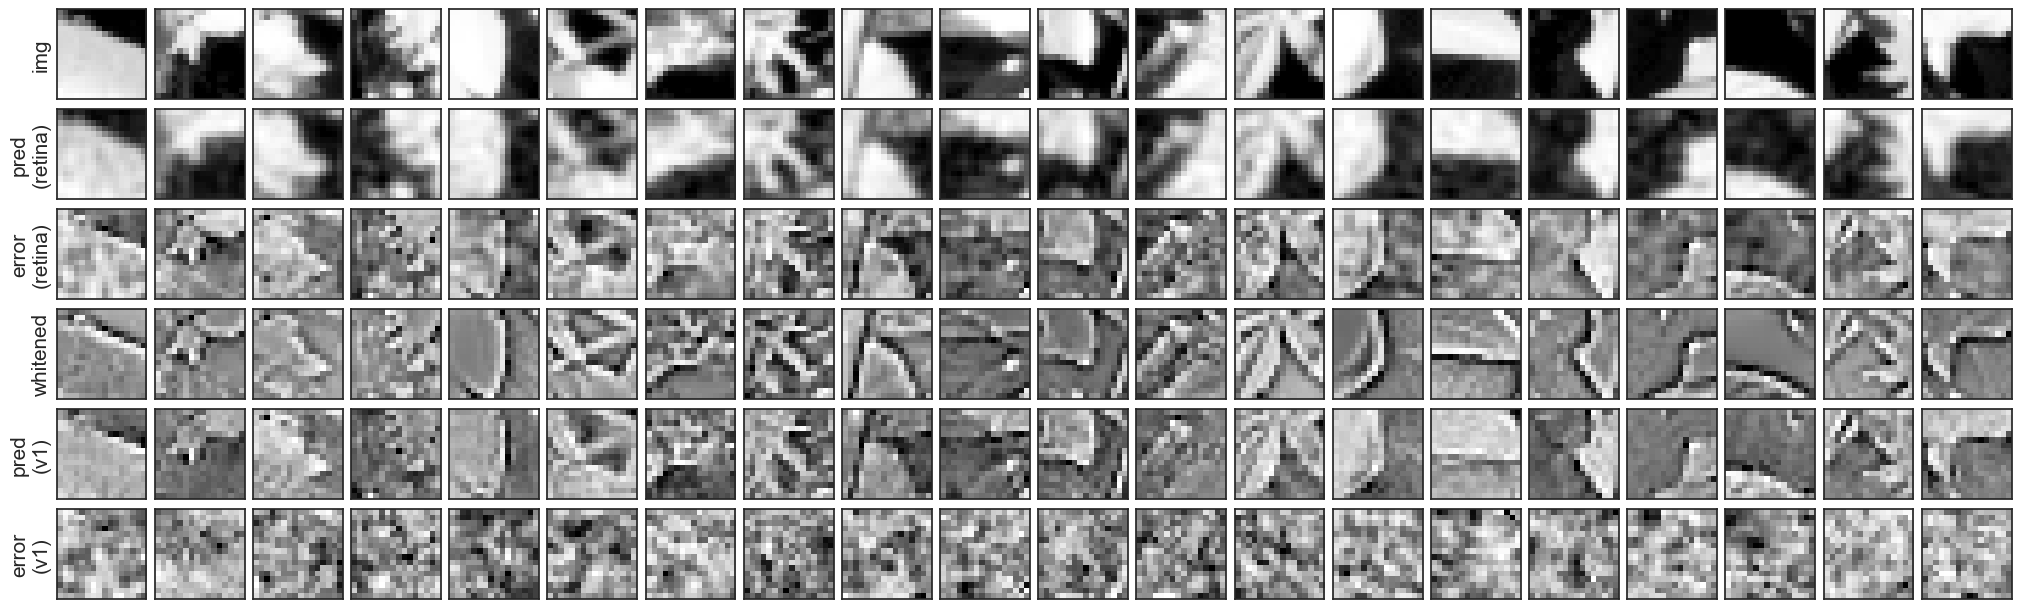

In [18]:
_plot_selected_samples()

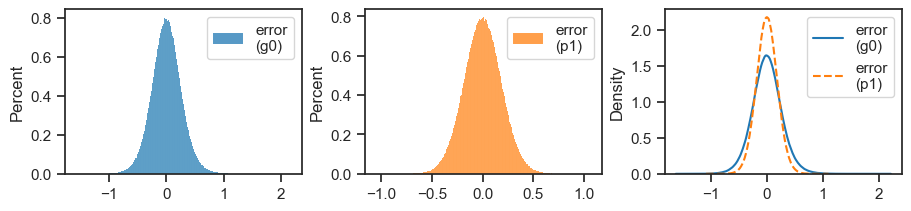

In [20]:
fig, axes = create_figure(1, len(error) + 1)

for i, (name, x2p) in enumerate(error.items()):
    sns.histplot(tonp(x2p.ravel()), stat='percent', color=f'C{i}', label=f'error\n({name})', ax=axes[i])
    sns.kdeplot(tonp(x2p.ravel()), color=f'C{i}', label=f'error\n({name})', ls='-' if i % 2 == 0 else '--', ax=axes[-1])
add_legend(axes)
plt.show()

In [21]:
for name, z in samples.items():
    life, pop, portions = sparse_score(z, cutoff=0.01)
    print(f"layer: {name}\nlifetime: {life.mean().item():0.3f}\nportions:{portions}\n")

layer: g0
lifetime: 0.280
portions:{'0': 46.6, '1': 53.4, '2': 0.0, '3+': 0}

layer: p1
lifetime: 0.917
portions:{'0': 84.9, '1': 4.5, '2': 3.0, '3': 2.1, '4': 1.5, '5': 1.0, '6': 0.8, '7+': 2.2}

In [19]:
print(tr.model.layers['p1'].n_exp)
tr.model.layers['p1'].posterior.n_exp

tensor([ 68,  85,  99, 109, 117, 122, 126, 128, 128, 127, 128, 127, 129, 126,
        127, 127], device='cuda:0', dtype=torch.int32)

172

## White noise

In [3]:
# a = 'g0+gomp,p1_Kyoto16-bw_t-[20+16]_b-[32,12]_k-[128,512]'
# b = 'b200-ep1200-lr(0.002)_temp(0.01:0.5)_gr(500)_(2025_04_14,23:12)'
# tr, meta = load_model(f"{a}/{b}", device=device)
# meta['checkpoint']

1200

In [4]:
print(tr.model.layers['p1'].n_exp)

tensor([12, 15, 17, 21, 27, 33, 36, 38, 39, 39, 39, 39, 39, 40, 40, 40],
       device='cuda:0', dtype=torch.int32)

In [5]:
print(tr.model.layers)

ModuleDict(
  (g0): GaussianGompertzLayer(input_dim=256, latent_dim=128, temperature=1, beta_inner=1, eps=1)
  (p1): PoissonLayer(input_dim=256, latent_dim=512, temperature=0.01, beta_inner=1, eps=1)
)

In [6]:
from analysis.sta import perform_sta_analysis
from utils.animation import show_movie

In [7]:
sta = perform_sta_analysis(tr, batch_size=10_000)

100%|█████████████████████████████████████████| 100/100 [35:44<00:00, 21.44s/it]


In [8]:
n_lags = 80
s_kers = {
    name: np_nans((len(sta_array), 16, 16))
    for name, sta_array in sta.items()
}
t_kers = {
    name: np_nans((len(sta_array), n_lags + 1))
    for name, sta_array in sta.items()
}

for name, sta_array in sta.items():
    for i in range(len(sta_array)):
        uu, ss, vvh = torch.linalg.svd(
            sta_array[i], full_matrices=False)
    
        s_kers[name][i] = tonp(vvh[0]).reshape(16, 16)
        t_kers[name][i] = tonp(uu[:, 0])

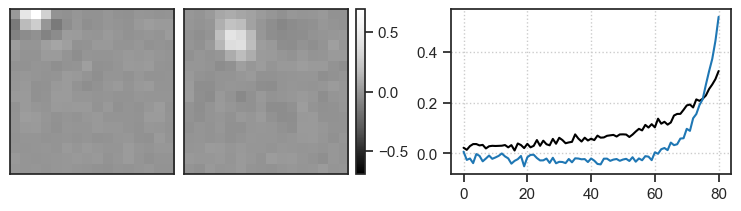

In [11]:
name = 'g0'
i, j = 57, 25
vminmax = np.abs(s_kers[name][[i, j]]).max()

fig, axes = create_figure(1, 3, (7.3, 2.0), width_ratios=[1, 1, 1.7])

im = axes[0].imshow(s_kers[name][i], cmap='Greys_r', vmin=-vminmax, vmax=vminmax)
im = axes[1].imshow(s_kers[name][j], cmap='Greys_r', vmin=-vminmax, vmax=vminmax)
plt.colorbar(im, ax=axes[1])

axes[2].plot(t_kers[name][i], color='k')
axes[2].plot(t_kers[name][j], color='C0')
axes[2].grid()

remove_ticks(axes[:2], False)
plt.show()

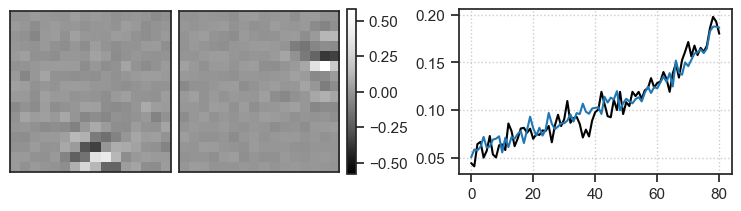

In [12]:
name = 'p1'
i, j = 57, 25
vminmax = np.abs(s_kers[name][[i, j]]).max()

fig, axes = create_figure(1, 3, (7.3, 2.0), width_ratios=[1, 1, 1.7])

im = axes[0].imshow(s_kers[name][i], cmap='Greys_r', vmin=-vminmax, vmax=vminmax)
im = axes[1].imshow(s_kers[name][j], cmap='Greys_r', vmin=-vminmax, vmax=vminmax)
plt.colorbar(im, ax=axes[1])

axes[2].plot(t_kers[name][i], color='k')
axes[2].plot(t_kers[name][j], color='C0')
axes[2].grid()

remove_ticks(axes[:2], False)
plt.show()

In [13]:
order = np.argsort(t_kers['g0'][:, 70])

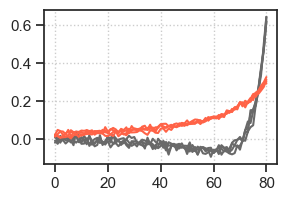

In [21]:
plot(t_kers['g0'][order][:4].T, color='dimgrey');
plot(t_kers['g0'][order][-4:].T, color='tomato');
plt.grid()
plt.show()

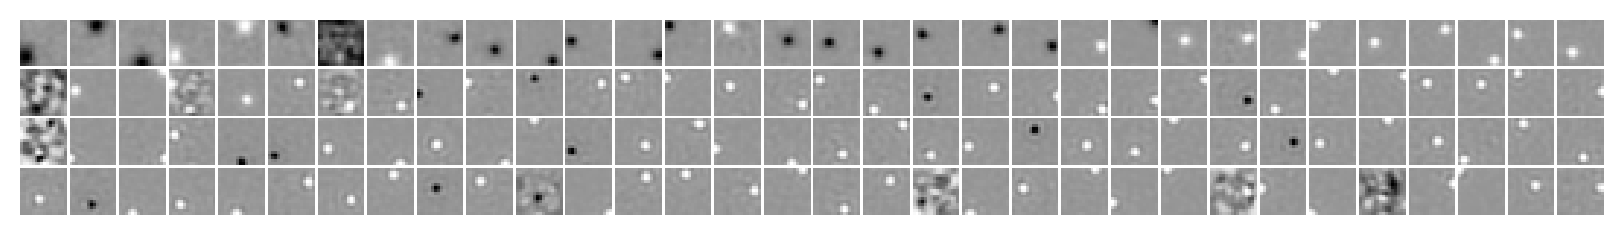

In [22]:
tr.model.show('g0', order=order, nrows=4, method='abs-max');
